In [60]:
from IPython.display import display, Latex
from IPython.core.display import HTML
%reset -f
%matplotlib inline
%autosave 300

import matplotlib.pyplot as plt
import numpy as np

Autosaving every 300 seconds


# Exercice 1 : 

### 4) Méthode du gradient 

In [61]:
def F(x):
    return x[0]**2 - x[1]**2 + 2*x[1]**4

def gradF(x):
    return np.array([2*x[0], -2*x[1] + 8*x[1]**3])

# Methode de gradient a pas constant h=0.1 avec point initial x0 = (1,0)

pas = 0.1
x0 = np.array([1.0, 0.0])
epsilon = 1e-8

x=x0
cpt=0
g=gradF(x)
while np.linalg.norm(g) > epsilon:
    x = x - pas * g
    g = gradF(x)
    print(x)
    cpt += 1
print("Nombre d'iterations: ", cpt)
print("Point de minimum: ", x)

[0.8 0. ]
[0.64 0.  ]
[0.512 0.   ]
[0.4096 0.    ]
[0.32768 0.     ]
[0.262144 0.      ]
[0.2097152 0.       ]
[0.16777216 0.        ]
[0.13421773 0.        ]
[0.10737418 0.        ]
[0.08589935 0.        ]
[0.06871948 0.        ]
[0.05497558 0.        ]
[0.04398047 0.        ]
[0.03518437 0.        ]
[0.0281475 0.       ]
[0.022518 0.      ]
[0.0180144 0.       ]
[0.01441152 0.        ]
[0.01152922 0.        ]
[0.00922337 0.        ]
[0.0073787 0.       ]
[0.00590296 0.        ]
[0.00472237 0.        ]
[0.00377789 0.        ]
[0.00302231 0.        ]
[0.00241785 0.        ]
[0.00193428 0.        ]
[0.00154743 0.        ]
[0.00123794 0.        ]
[0.00099035 0.        ]
[0.00079228 0.        ]
[0.00063383 0.        ]
[0.00050706 0.        ]
[0.00040565 0.        ]
[0.00032452 0.        ]
[0.00025961 0.        ]
[0.00020769 0.        ]
[0.00016615 0.        ]
[0.00013292 0.        ]
[0.00010634 0.        ]
[8.50705917e-05 0.00000000e+00]
[6.80564734e-05 0.00000000e+00]
[5.44451787e-05 0.

### 5) Armijo avec x0 = (1,0) et x0 = (1,1)

In [62]:
# Armijo avec x0 = (1,0) et x0 = (1,1)

def armijo(x,f,gradfx,alpha,m1):
    delta=alpha
    q = lambda t : f(x-t*gradfx)
    q0=q(0)
    qp0=-np.linalg.norm(gradfx)**2
    while q(delta) > q0+m1*qp0*delta :
        delta = delta/2
    return delta

# x0 = np.array([1.0, 0.0])
x0 = np.array([1.0, 1.0])
x = x0
ALPHA = 1
M1 = 0.3
cpt = 0
while np.linalg.norm(gradF(x)) > epsilon:
    g = gradF(x)
    alpha = armijo(x, F, g, ALPHA, M1)
    x = x - alpha * g
    print(x)
    cpt += 1
print("Nombre d'iterations: ", cpt)
print("Point de minimum: ", x)

[0.875 0.625]
[0.        0.2734375]
[0.         0.46509743]
[0.         0.49643047]
[0.         0.49996187]
[0.  0.5]
[0.  0.5]
Nombre d'iterations:  7
Point de minimum:  [0.  0.5]


# Exercice 2 : 

In [63]:
B = np.array([[14, -34, -18], [-34, 152, 90], [-18, 90, 54]])
b = np.array([-8, -50, -36])

def F(x):
    return B@x - b

# f(x) = 0.5 * norme_euclidienne(B@x - b)**2 sur R^3

def f(x):
    return 0.5 * np.linalg.norm(F(x))**2


# Gradient a pas constant pour trouver un min de f
x0 = np.zeros(B.shape[1])
epsilon = 1e-7
pas = 1.e-6

x = x0.copy()
cpt = 0
g = F(x)
while np.linalg.norm(g) > epsilon:
    x = x - pas * g
    g = F(x)
    cpt += 1
print("Nombre d'iterations: ", cpt)
print("Point de minimum: ", x)


# Gradient a pas optimal pour trouver un min de f
x0 = np.zeros(B.shape[1])
epsilon = 1e-7
x = x0.copy()
cpt = 0
g = F(x)
while np.linalg.norm(g) > epsilon:
    pas = (g.T @ g) / (g.T @ B @ g)
    x = x - pas * g
    g = F(x)
    cpt += 1
print("Nombre d'iterations: ", cpt)
print("Point de minimum: ", x)

# Gradient avec armijo pour trouver un min de f
x0 = np.zeros(B.shape[1])
epsilon = 1e-7
ALPHA = 1
M1 = 0.3
x = x0.copy()
cpt = 0
g = F(x)
while np.linalg.norm(g) > epsilon:
    pas = armijo(x, f, g, ALPHA, M1)
    x = x - pas * g
    g = F(x)
    cpt += 1
print("Nombre d'iterations: ", cpt)
print("Point de minimum: ", x)




Nombre d'iterations:  2693145
Point de minimum:  [-2.64285713 -0.28571429 -1.07142857]
Nombre d'iterations:  123
Point de minimum:  [-2.64285713 -0.28571429 -1.07142857]
Nombre d'iterations:  263
Point de minimum:  [-2.64285713 -0.28571429 -1.07142857]


# Exercice 3 : 

Gradient de f en x0:  [ -60. -205.  -70. -301. -193. -279. -333.]
Hessien de f en x0:  [[ 11  17 -19   7   7  29  32]
 [ 17  49  -3  59  34  63  74]
 [-19  -3  83  55  33 -15 -10]
 [  7  59  55 113  64  65  82]
 [  7  34  33  64  45  50  61]
 [ 29  63 -15  65  50 101 116]
 [ 32  74 -10  82  61 116 134]]
Valeurs propres du Hessien:  [ 3.79944983e+02+0.00000000e+00j  1.39497932e+02+0.00000000e+00j
  1.65570851e+01+0.00000000e+00j -1.73695559e-14+0.00000000e+00j
 -4.09157128e-17+0.00000000e+00j  5.15057153e-15+2.36306322e-15j
  5.15057153e-15-2.36306322e-15j]
Nombre d'iterations:  674027
Point de minimum:  [0.1149506  0.73509373 0.19049708 1.10773739 0.40255547 0.56501616
 0.71565237]
Gradient Armijo :
Nombre d'iterations:  113
Point de minimum:  [0.11495061 0.73509433 0.1904967  1.10773804 0.40255511 0.56501591
 0.71565215]


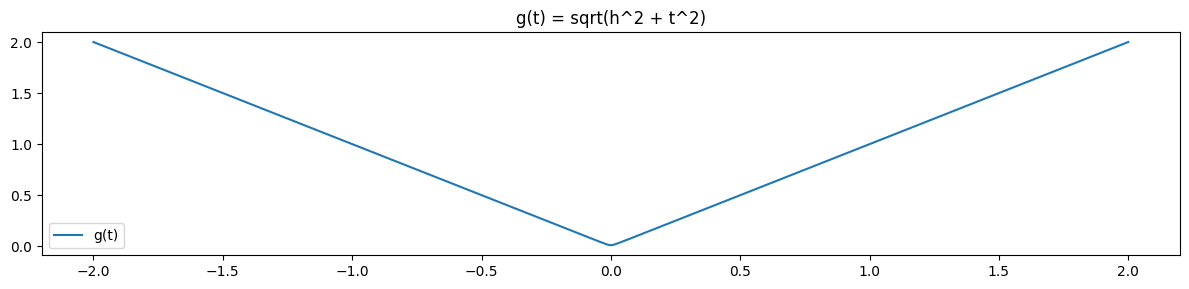

In [64]:
# On veut résoudre le systeme lineaire A.x = b

A = np.array([[1,2,3,4,5,6,7],[-1,3,7,9,4,1,2],[3,6,-5,4,2,8,9]])
# b = A@np.array([0,1,0,1,1,1,0]) # = (17,17,20)T
b = np.array([17,17,20])

h=1e-2


# f(x) = 0.5 * norme_euclidienne(A@x - b)**2

def f(x):
    return 0.5 * np.linalg.norm(A@x - b)**2

def gradf(x):
    return A.T@(A@x - b)

def Hessien(x):
    return A.T@A

x = np.zeros(7)
x0 = x

print("Gradient de f en x0: ", gradf(x0))
print("Hessien de f en x0: ", Hessien(x0))
print("Valeurs propres du Hessien: ", np.linalg.eigvals(Hessien(x0)))

# Calculer derivee premiere et seconde de t -> racine(h**2 + t**2). est-elle convexe sur R ? (tracer graphe sur [-2,2])
def g(t):
    return np.sqrt(h**2 + t**2)

def g_prime(t):
    return t / np.sqrt(h**2 + t**2)

def g_double_prime(t):
    return h**2 / (h**2 + t**2)**(3/2)

t_values = np.linspace(-2, 2, 400)
g_values = g(t_values)
g_prime_values = g_prime(t_values)
g_double_prime_values = g_double_prime(t_values)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(t_values, g_values, label='g(t)')
plt.title('g(t) = sqrt(h^2 + t^2)')
plt.legend()
plt.tight_layout()


# min {f(x) := 1/2 * norme_euclidienne(A@x - b)**2 + somme_i=1^7 racine(h**2 + x[i]**2) : x in R^7}
h=1e-2

x0 = np.zeros(7)
epsilon = 1e-4
x = x0
pas = 1e-6
# On comparera le nombre d'iterations et les vitesses de convergences de ces methodes
# Methode du gradient a pas constant 
def methode_pas_constant(gradf,x0,delta,epsilon):
    x=x0
    cpt=0
    g=gradf(x)
    while np.linalg.norm(g) > epsilon :
        x = x - delta * g
        g=gradf(x)
        cpt += 1
    return [x,cpt]

x1, cpt1 = methode_pas_constant(gradf,x0,pas,epsilon)
print("Nombre d'iterations: ", cpt1)
print("Point de minimum: ", x1)



# Méthode du gradient avec recherche d'Armijo
def armijo(x, f, gradfx, alpha, m1):
    delta = alpha
    q = lambda t: f(x - t * gradfx)
    q0 = q(0)
    qp0 = -np.linalg.norm(gradfx) ** 2
    while q(delta) > q0 + m1 * qp0 * delta:
        delta = delta / 2
    return delta

print("Gradient Armijo :")
x = x0.copy()
ALPHA = 1
M1 = 0.3
cpt = 0

while np.linalg.norm(gradf(x)) > epsilon:
    g = gradf(x)
    alpha = armijo(x, f, g, ALPHA, M1)
    x = x - alpha * g
    # print(x)
    cpt += 1

print("Nombre d'iterations: ", cpt)
print("Point de minimum: ", x)



In [66]:
# f(x) = F(x) + G(x) avec F(x) = 0.5 * norme_euclidienne(A@x - b)**2 et G(x) = somme_i=1^7 racine(h**2 + x[i]**2)

# algorithme :
x0 = np.zeros(7)
teta = 1e-6
precision_local = 1e-6
precision = 1e-6

x = x0.copy()
y = x0.copy()
v = x0.copy()

    
# Appliquer algorithme avec gradient armijo en F et G ou teta = 0.25 et precision_locale = precision/20


